In [35]:
import numpy as np

# Objective function
def f(theta):
    return theta**2

# Gradient of f(theta) = theta^2
def gradient(theta):
    return 2 * theta

# Initial parameter
theta = 10.0

# Adam hyperparameters
learning_rate = 0.1
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8

print("Initial theta:", theta)
print("Initial loss:", f(theta))
print("Initial gradient:", gradient(theta))

Initial theta: 10.0
Initial loss: 100.0
Initial gradient: 20.0


In [36]:
# Adam's internal state

m = 0.0      # First moment estimate
v = 0.0      # Second moment estimate
t = 0        # Time step

print("Initial m:", m)
print("Initial v:", v)
print("Initial t:", t)

Initial m: 0.0
Initial v: 0.0
Initial t: 0


In [37]:
# Run Adam for 100 iterations

for i in range(100):
    
    # 1. Calculate gradient
    g = gradient(theta)
    
    # 2. Increase timestep
    t += 1
    
    # 3. Update first moment
    m = beta1 * m + (1 - beta1) * g
    
    # 4. Update second moment
    v = beta2 * v + (1 - beta2) * (g ** 2)
    
    # 5. Bias correction
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    
    # 6. Update parameter
    theta = theta - learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
    
    # Print progress
    if (i + 1) % 10 == 0:
        print(
            f"Iteration {i + 1}: "
            f"theta = {theta:.6f}, "
            f"loss = {f(theta):.6f}"
        )

Iteration 10: theta = 9.003497, loss = 81.062950
Iteration 20: theta = 8.026664, loss = 64.427342
Iteration 30: theta = 7.086813, loss = 50.222918
Iteration 40: theta = 6.197538, loss = 38.409482
Iteration 50: theta = 5.368212, loss = 28.817697
Iteration 60: theta = 4.604658, loss = 21.202871
Iteration 70: theta = 3.910058, loss = 15.288553
Iteration 80: theta = 3.285624, loss = 10.795326
Iteration 90: theta = 2.730994, loss = 7.458329
Iteration 100: theta = 2.244460, loss = 5.037603


In [38]:
# Track optimization history

theta_history = []
loss_history = []

# Reset Adam variables
theta = 10.0
m = 0.0
v = 0.0
t = 0

for i in range(100):
    
    # Calculate gradient
    g = gradient(theta)
    
    # Update timestep
    t += 1
    
    # First moment
    m = beta1 * m + (1 - beta1) * g
    
    # Second moment
    v = beta2 * v + (1 - beta2) * (g ** 2)
    
    # Bias correction
    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)
    
    # Update theta
    theta = theta - learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
    
    # Store values
    theta_history.append(theta)
    loss_history.append(f(theta))

print("Final theta:", theta)
print("Final loss:", f(theta))

Final theta: 2.2444604231601724
Final loss: 5.03760259113234


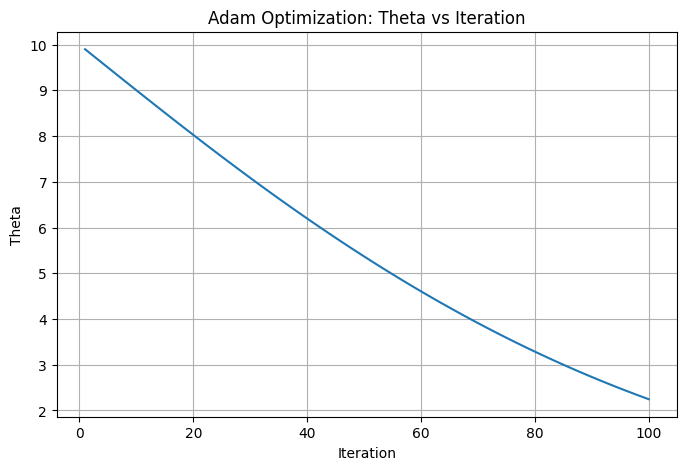

In [39]:
import matplotlib.pyplot as plt

# Plot theta over iterations
plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), theta_history)
plt.xlabel("Iteration")
plt.ylabel("Theta")
plt.title("Adam Optimization: Theta vs Iteration")
plt.grid(True)
plt.show()

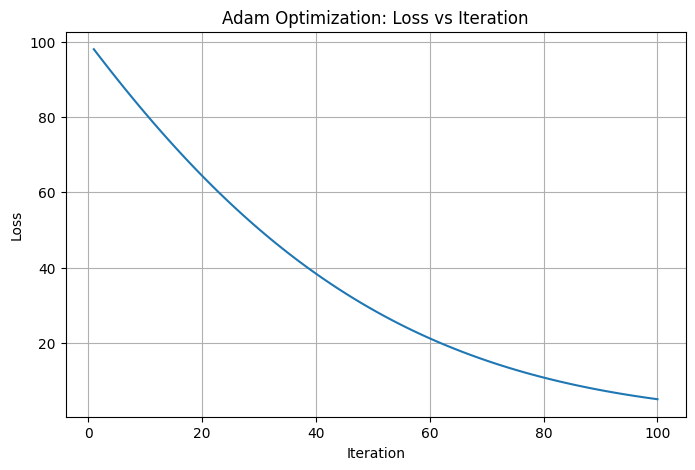

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 101), loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Adam Optimization: Loss vs Iteration")
plt.grid(True)
plt.show()

In [41]:
# XOR dataset

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

print("X:")
print(X)

print("\ny:")
print(y)

X:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

y:
[[0.]
 [1.]
 [1.]
 [0.]]


In [42]:
# Neural network architecture
input_size = 2
hidden_size = 4
output_size = 1

# Set random seed for reproducibility
np.random.seed(42)

# Initialize weights and biases
W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1 / input_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1 / hidden_size)
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (2, 4)
b1 shape: (1, 4)
W2 shape: (4, 1)
b2 shape: (1, 1)


In [43]:
# Activation functions

def tanh(x):
    return np.tanh(x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

print("tanh(0):", tanh(0))
print("sigmoid(0):", sigmoid(0))

tanh(0): 0.0
sigmoid(0): 0.5


In [44]:
# Forward pass

# Hidden layer
Z1 = X @ W1 + b1
A1 = tanh(Z1)

# Output layer
Z2 = A1 @ W2 + b2
y_pred = sigmoid(Z2)

print("Hidden layer output (A1):")
print(A1)

print("\nPredictions:")
print(y_pred)

Hidden layer output (A1):
[[ 0.          0.          0.          0.        ]
 [-0.16407486 -0.16406356  0.80640825  0.49499756]
 [ 0.33746587 -0.09745731  0.42844047  0.79206335]
 [ 0.18355435 -0.25740517  0.91776337  0.92456661]]

Predictions:
[[0.5       ]
 [0.4235756 ]
 [0.40386868]
 [0.36798548]]


In [45]:
# Binary Cross-Entropy Loss

def binary_cross_entropy(y, y_pred):
    epsilon = 1e-8
    
    # Prevent log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    loss = -np.mean(
        y * np.log(y_pred) +
        (1 - y) * np.log(1 - y_pred)
    )
    
    return loss


loss = binary_cross_entropy(y, y_pred)

print("Initial loss:", loss)

Initial loss: 0.7294197109945458


In [46]:
# Backpropagation

n = X.shape[0]

# Gradient of loss with respect to Z2
dZ2 = (y_pred - y) / n

# Gradients for second layer
dW2 = A1.T @ dZ2
db2 = np.sum(dZ2, axis=0, keepdims=True)

# Gradient flowing back into hidden layer
dA1 = dZ2 @ W2.T

# Derivative of tanh
dZ1 = dA1 * (1 - A1**2)

# Gradients for first layer
dW1 = X.T @ dZ1
db1 = np.sum(dZ1, axis=0, keepdims=True)

print("dW1 shape:", dW1.shape)
print("db1 shape:", db1.shape)
print("dW2 shape:", dW2.shape)
print("db2 shape:", db2.shape)

dW1 shape: (2, 4)
db1 shape: (1, 4)
dW2 shape: (4, 1)
db2 shape: (1, 1)


In [47]:
# Initialize Adam's moment estimates for each parameter

mW1 = np.zeros_like(W1)
vW1 = np.zeros_like(W1)

mb1 = np.zeros_like(b1)
vb1 = np.zeros_like(b1)

mW2 = np.zeros_like(W2)
vW2 = np.zeros_like(W2)

mb2 = np.zeros_like(b2)
vb2 = np.zeros_like(b2)

# Adam timestep
t = 0

print("Adam states initialized.")
print("mW1:", mW1.shape)
print("vW1:", vW1.shape)
print("mW2:", mW2.shape)
print("vW2:", vW2.shape)

Adam states initialized.
mW1: (2, 4)
vW1: (2, 4)
mW2: (4, 1)
vW2: (4, 1)


In [48]:
# Train the neural network using Adam

epochs = 5000

loss_history = []

for epoch in range(epochs):

    # --------------------------------------------------
    # 1. FORWARD PASS
    # --------------------------------------------------
    
    Z1 = X @ W1 + b1
    A1 = tanh(Z1)

    Z2 = A1 @ W2 + b2
    y_pred = sigmoid(Z2)

    
    # --------------------------------------------------
    # 2. CALCULATE LOSS
    # --------------------------------------------------
    
    loss = binary_cross_entropy(y, y_pred)
    loss_history.append(loss)

    
    # --------------------------------------------------
    # 3. BACKPROPAGATION
    # --------------------------------------------------
    
    n = X.shape[0]

    dZ2 = (y_pred - y) / n

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * (1 - A1**2)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    
    # --------------------------------------------------
    # 4. ADAM
    # --------------------------------------------------
    
    t += 1

    # First moment
    mW1 = beta1 * mW1 + (1 - beta1) * dW1
    mb1 = beta1 * mb1 + (1 - beta1) * db1

    mW2 = beta1 * mW2 + (1 - beta1) * dW2
    mb2 = beta1 * mb2 + (1 - beta1) * db2

    # Second moment
    vW1 = beta2 * vW1 + (1 - beta2) * (dW1 ** 2)
    vb1 = beta2 * vb1 + (1 - beta2) * (db1 ** 2)

    vW2 = beta2 * vW2 + (1 - beta2) * (dW2 ** 2)
    vb2 = beta2 * vb2 + (1 - beta2) * (db2 ** 2)

    
    # --------------------------------------------------
    # 5. BIAS CORRECTION
    # --------------------------------------------------
    
    mW1_hat = mW1 / (1 - beta1 ** t)
    mb1_hat = mb1 / (1 - beta1 ** t)

    mW2_hat = mW2 / (1 - beta1 ** t)
    mb2_hat = mb2 / (1 - beta1 ** t)

    vW1_hat = vW1 / (1 - beta2 ** t)
    vb1_hat = vb1 / (1 - beta2 ** t)

    vW2_hat = vW2 / (1 - beta2 ** t)
    vb2_hat = vb2 / (1 - beta2 ** t)

    
    # --------------------------------------------------
    # 6. UPDATE PARAMETERS
    # --------------------------------------------------
    
    W1 -= learning_rate * mW1_hat / (np.sqrt(vW1_hat) + epsilon)
    b1 -= learning_rate * mb1_hat / (np.sqrt(vb1_hat) + epsilon)

    W2 -= learning_rate * mW2_hat / (np.sqrt(vW2_hat) + epsilon)
    b2 -= learning_rate * mb2_hat / (np.sqrt(vb2_hat) + epsilon)

    
    # --------------------------------------------------
    # 7. PRINT PROGRESS
    # --------------------------------------------------
    
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}: Loss = {loss:.6f}")

Epoch 500: Loss = 0.000463
Epoch 1000: Loss = 0.000158
Epoch 1500: Loss = 0.000080
Epoch 2000: Loss = 0.000047
Epoch 2500: Loss = 0.000031
Epoch 3000: Loss = 0.000021
Epoch 3500: Loss = 0.000015
Epoch 4000: Loss = 0.000011
Epoch 4500: Loss = 0.000008
Epoch 5000: Loss = 0.000006


In [49]:
# Test the trained neural network

Z1 = X @ W1 + b1
A1 = tanh(Z1)

Z2 = A1 @ W2 + b2
y_pred = sigmoid(Z2)

print("Predictions:")
print(y_pred)

print("\nRounded predictions:")
print(np.round(y_pred))

print("\nActual labels:")
print(y)

Predictions:
[[1.14003288e-07]
 [9.99994716e-01]
 [9.99990093e-01]
 [8.68342740e-06]]

Rounded predictions:
[[0.]
 [1.]
 [1.]
 [0.]]

Actual labels:
[[0.]
 [1.]
 [1.]
 [0.]]


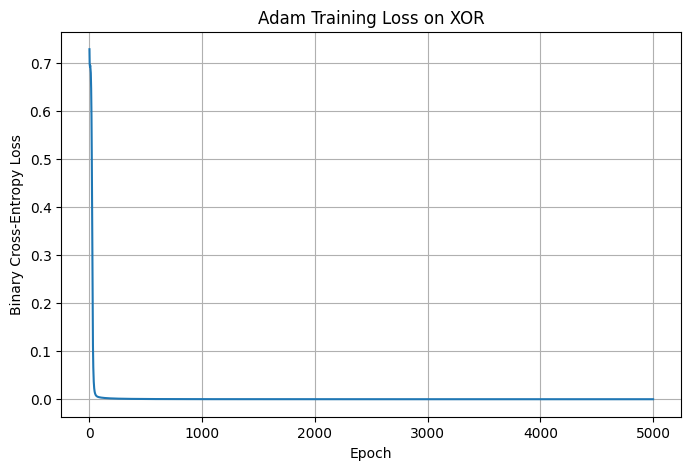

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Adam Training Loss on XOR")

plt.grid(True)
plt.show()

In [51]:
def initialize_network(seed=42):
    np.random.seed(seed)

    W1 = np.random.randn(2, 4) * np.sqrt(1 / 2)
    b1 = np.zeros((1, 4))

    W2 = np.random.randn(4, 1) * np.sqrt(1 / 4)
    b2 = np.zeros((1, 1))

    return W1, b1, W2, b2


# Create the same starting point for all optimizers
W1_init, b1_init, W2_init, b2_init = initialize_network()

print("W1 initial shape:", W1_init.shape)
print("b1 initial shape:", b1_init.shape)
print("W2 initial shape:", W2_init.shape)
print("b2 initial shape:", b2_init.shape)

W1 initial shape: (2, 4)
b1 initial shape: (1, 4)
W2 initial shape: (4, 1)
b2 initial shape: (1, 1)


In [52]:
def forward_backward(X, y, W1, b1, W2, b2):
    
    # -------------------------
    # Forward pass
    # -------------------------
    
    Z1 = X @ W1 + b1
    A1 = tanh(Z1)
    
    Z2 = A1 @ W2 + b2
    y_pred = sigmoid(Z2)
    
    # Calculate loss
    loss = binary_cross_entropy(y, y_pred)
    
    # -------------------------
    # Backpropagation
    # -------------------------
    
    n = X.shape[0]
    
    dZ2 = (y_pred - y) / n
    
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    
    dA1 = dZ2 @ W2.T
    
    dZ1 = dA1 * (1 - A1**2)
    
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    return loss, dW1, db1, dW2, db2

In [53]:
# Train XOR using plain SGD

W1_sgd = W1_init.copy()
b1_sgd = b1_init.copy()
W2_sgd = W2_init.copy()
b2_sgd = b2_init.copy()

learning_rate_sgd = 0.5
epochs = 5000

sgd_loss_history = []

for epoch in range(epochs):

    # Forward pass + backpropagation
    loss, dW1, db1, dW2, db2 = forward_backward(
        X, y,
        W1_sgd, b1_sgd,
        W2_sgd, b2_sgd
    )

    # Store loss
    sgd_loss_history.append(loss)

    # SGD parameter updates
    W1_sgd -= learning_rate_sgd * dW1
    b1_sgd -= learning_rate_sgd * db1

    W2_sgd -= learning_rate_sgd * dW2
    b2_sgd -= learning_rate_sgd * db2

    # Print progress
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}: Loss = {loss:.6f}")

Epoch 500: Loss = 0.014327
Epoch 1000: Loss = 0.005727
Epoch 1500: Loss = 0.003560
Epoch 2000: Loss = 0.002580
Epoch 2500: Loss = 0.002022
Epoch 3000: Loss = 0.001662
Epoch 3500: Loss = 0.001410
Epoch 4000: Loss = 0.001225
Epoch 4500: Loss = 0.001083
Epoch 5000: Loss = 0.000970


In [54]:
# Train XOR using Momentum

W1_mom = W1_init.copy()
b1_mom = b1_init.copy()
W2_mom = W2_init.copy()
b2_mom = b2_init.copy()

learning_rate_momentum = 0.5
beta = 0.9
epochs = 5000

# Initialize velocity
vW1 = np.zeros_like(W1_mom)
vb1 = np.zeros_like(b1_mom)

vW2 = np.zeros_like(W2_mom)
vb2 = np.zeros_like(b2_mom)

momentum_loss_history = []

for epoch in range(epochs):

    # Forward pass + backpropagation
    loss, dW1, db1, dW2, db2 = forward_backward(
        X, y,
        W1_mom, b1_mom,
        W2_mom, b2_mom
    )

    # Store loss
    momentum_loss_history.append(loss)

    # Update velocities
    vW1 = beta * vW1 + dW1
    vb1 = beta * vb1 + db1

    vW2 = beta * vW2 + dW2
    vb2 = beta * vb2 + db2

    # Update parameters
    W1_mom -= learning_rate_momentum * vW1
    b1_mom -= learning_rate_momentum * vb1

    W2_mom -= learning_rate_momentum * vW2
    b2_mom -= learning_rate_momentum * vb2

    # Print progress
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}: Loss = {loss:.6f}")

Epoch 500: Loss = 0.000936
Epoch 1000: Loss = 0.000449
Epoch 1500: Loss = 0.000281
Epoch 2000: Loss = 0.000202
Epoch 2500: Loss = 0.000157
Epoch 3000: Loss = 0.000128
Epoch 3500: Loss = 0.000109
Epoch 4000: Loss = 0.000094
Epoch 4500: Loss = 0.000083
Epoch 5000: Loss = 0.000075


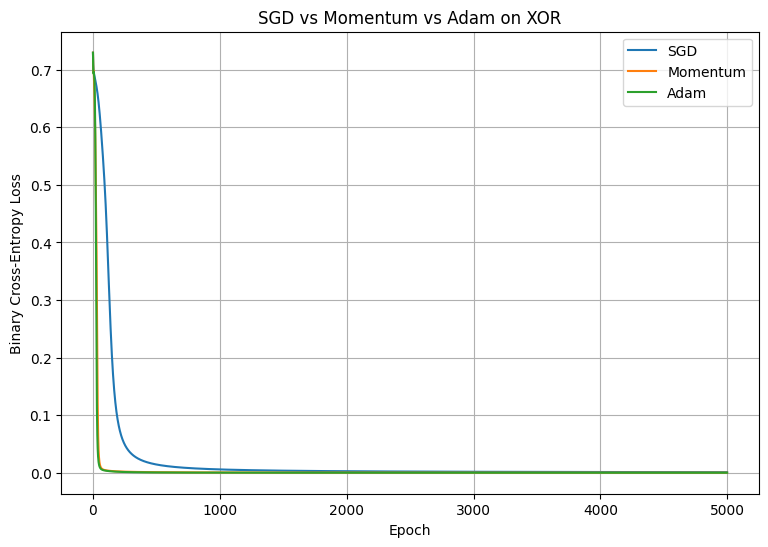

In [55]:
# Compare SGD, Momentum, and Adam

plt.figure(figsize=(9, 6))

plt.plot(sgd_loss_history, label="SGD")
plt.plot(momentum_loss_history, label="Momentum")
plt.plot(loss_history, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("SGD vs Momentum vs Adam on XOR")

plt.legend()
plt.grid(True)

plt.show()

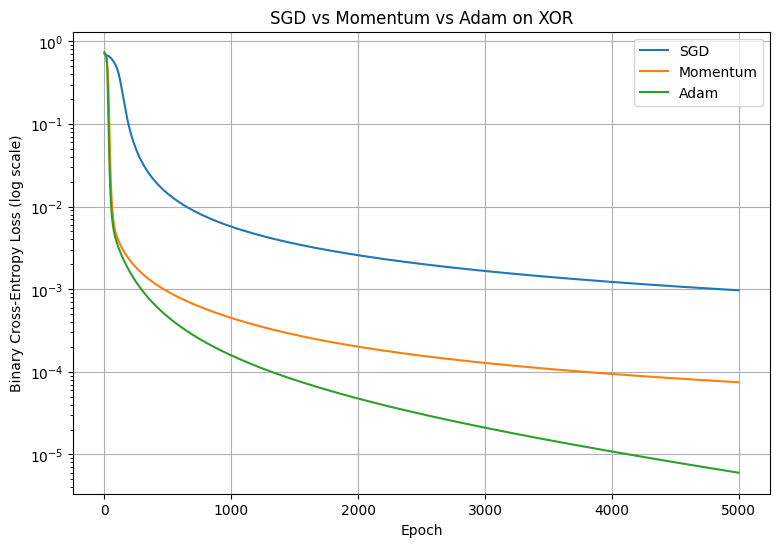

In [56]:
# Compare optimizers using a logarithmic y-axis

plt.figure(figsize=(9, 6))

plt.plot(sgd_loss_history, label="SGD")
plt.plot(momentum_loss_history, label="Momentum")
plt.plot(loss_history, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss (log scale)")
plt.title("SGD vs Momentum vs Adam on XOR")

plt.yscale("log")

plt.legend()
plt.grid(True)

plt.show()

In [57]:
# Learning rates we want to compare

learning_rates = [0.001, 0.01, 0.1, 0.5]

print("Learning rates to test:")
print(learning_rates)

Learning rates to test:
[0.001, 0.01, 0.1, 0.5]


In [58]:
# Compare Adam with different learning rates

adam_lr_histories = {}

epochs = 1000

for lr in learning_rates:
    
    # Start from exactly the same initial weights
    W1_lr = W1_init.copy()
    b1_lr = b1_init.copy()
    W2_lr = W2_init.copy()
    b2_lr = b2_init.copy()
    
    # Adam states
    mW1_lr = np.zeros_like(W1_lr)
    vW1_lr = np.zeros_like(W1_lr)

    mb1_lr = np.zeros_like(b1_lr)
    vb1_lr = np.zeros_like(b1_lr)

    mW2_lr = np.zeros_like(W2_lr)
    vW2_lr = np.zeros_like(W2_lr)

    mb2_lr = np.zeros_like(b2_lr)
    vb2_lr = np.zeros_like(b2_lr)

    t_lr = 0
    
    loss_history_lr = []

    # Training
    for epoch in range(epochs):

        # Forward + backward
        loss, dW1, db1, dW2, db2 = forward_backward(
            X, y,
            W1_lr, b1_lr,
            W2_lr, b2_lr
        )

        loss_history_lr.append(loss)

        # Time step
        t_lr += 1

        # First moments
        mW1_lr = beta1 * mW1_lr + (1 - beta1) * dW1
        mb1_lr = beta1 * mb1_lr + (1 - beta1) * db1

        mW2_lr = beta1 * mW2_lr + (1 - beta1) * dW2
        mb2_lr = beta1 * mb2_lr + (1 - beta1) * db2

        # Second moments
        vW1_lr = beta2 * vW1_lr + (1 - beta2) * (dW1 ** 2)
        vb1_lr = beta2 * vb1_lr + (1 - beta2) * (db1 ** 2)

        vW2_lr = beta2 * vW2_lr + (1 - beta2) * (dW2 ** 2)
        vb2_lr = beta2 * vb2_lr + (1 - beta2) * (db2 ** 2)

        # Bias correction
        mW1_hat = mW1_lr / (1 - beta1 ** t_lr)
        mb1_hat = mb1_lr / (1 - beta1 ** t_lr)

        mW2_hat = mW2_lr / (1 - beta1 ** t_lr)
        mb2_hat = mb2_lr / (1 - beta1 ** t_lr)

        vW1_hat = vW1_lr / (1 - beta2 ** t_lr)
        vb1_hat = vb1_lr / (1 - beta2 ** t_lr)

        vW2_hat = vW2_lr / (1 - beta2 ** t_lr)
        vb2_hat = vb2_lr / (1 - beta2 ** t_lr)

        # Adam updates
        W1_lr -= lr * mW1_hat / (np.sqrt(vW1_hat) + epsilon)
        b1_lr -= lr * mb1_hat / (np.sqrt(vb1_hat) + epsilon)

        W2_lr -= lr * mW2_hat / (np.sqrt(vW2_hat) + epsilon)
        b2_lr -= lr * mb2_hat / (np.sqrt(vb2_hat) + epsilon)

    # Save loss history
    adam_lr_histories[lr] = loss_history_lr

    print(f"Learning rate {lr}: Final loss = {loss_history_lr[-1]:.6f}")

Learning rate 0.001: Final loss = 0.411976
Learning rate 0.01: Final loss = 0.005772
Learning rate 0.1: Final loss = 0.000158
Learning rate 0.5: Final loss = 0.000061


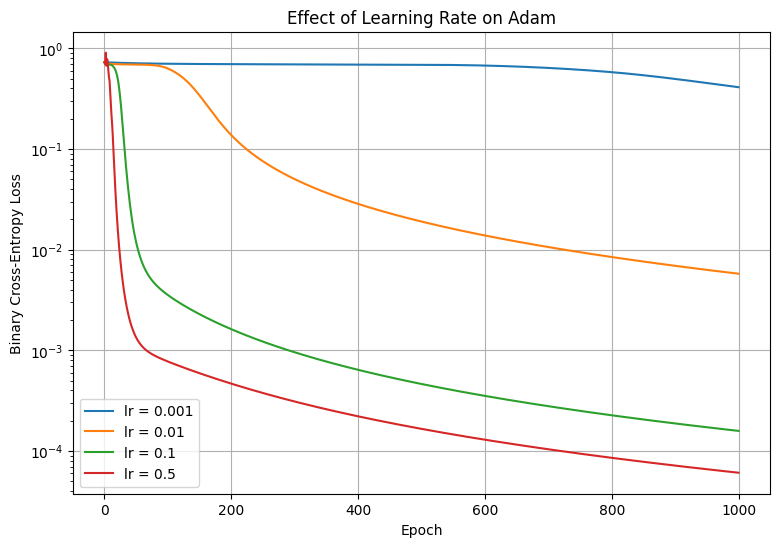

In [59]:
# Plot Adam with different learning rates

plt.figure(figsize=(9, 6))

for lr in learning_rates:
    plt.plot(
        adam_lr_histories[lr],
        label=f"lr = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Effect of Learning Rate on Adam")

plt.yscale("log")

plt.legend()
plt.grid(True)

plt.show()

In [60]:
# Final optimizer comparison

print("Optimizer Comparison")
print("-" * 40)
print(f"SGD      : {sgd_loss_history[-1]:.6f}")
print(f"Momentum : {momentum_loss_history[-1]:.6f}")
print(f"Adam     : {loss_history[-1]:.6f}")

print("\nAdam Learning Rate Comparison")
print("-" * 40)

for lr in learning_rates:
    print(f"lr = {lr:<5}: {adam_lr_histories[lr][-1]:.6f}")

Optimizer Comparison
----------------------------------------
SGD      : 0.000970
Momentum : 0.000075
Adam     : 0.000006

Adam Learning Rate Comparison
----------------------------------------
lr = 0.001: 0.411976
lr = 0.01 : 0.005772
lr = 0.1  : 0.000158
lr = 0.5  : 0.000061
